In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from core.data import load_from_kaggle


c:\Users\hjgxh\OneDrive\Документы\GitHub\DPP-1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_link = "mexwell/amazon-reviews-multi" # replace with your dataset link from Kaggle 
destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
    )

Destination directory '../data/raw\amazon-reviews-multi' already exists with files. Skipping download (replace=False).


In [3]:
files

['test.csv', 'train.csv', 'validation.csv']

In [ ]:
# PHASE 1.1: Data Consolidation (Datenkonsolidierung)

# Merging train, test, and validation sets using your join approach
all_paths = ["/".join(["../data/raw", dataset_name, f]) for f in files]
df = pd.concat([pd.read_csv(p) for p in all_paths], ignore_index=True)

# PHASE 1.2: Health Audit (Daten-Audit)

# Identifying data quality issues before processing
print(f"Total records loaded: {len(df)}")
print(f"Exact duplicates found: {df.duplicated().sum()}")
print("\nMissing values per column:")
print(df.isnull().sum())

# Checking current data types and memory usage
print("\nInitial Data Info:")
df.info()

Total records loaded: 1260000
Exact duplicates found: 0

Missing values per column:
Unnamed: 0           0
review_id            0
product_id           0
reviewer_id          0
stars                0
review_body          0
review_title        46
language             0
product_category     0
dtype: int64

Initial Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260000 entries, 0 to 1259999
Data columns (total 9 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   Unnamed: 0        1260000 non-null  int64 
 1   review_id         1260000 non-null  object
 2   product_id        1260000 non-null  object
 3   reviewer_id       1260000 non-null  object
 4   stars             1260000 non-null  int64 
 5   review_body       1260000 non-null  object
 6   review_title      1259954 non-null  object
 7   language          1260000 non-null  object
 8   product_category  1260000 non-null  object
dtypes: int64(2), object(7)
memory u

In [20]:
# PHASE 1.3: Data Cleaning (Datenbereinigung)

# Filling the 46 missing titles with a placeholder
df['review_title'] = df['review_title'].fillna('No Title')

# Removing the technical noise column 'Unnamed: 0'
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
print("✅ Column 'Unnamed: 0' successfully removed.")
display(df.head())

# PHASE 1.4: Memory Optimization (Speicheroptimierung) 

# Optimizing data types: int8 for ratings, category for strings
df['stars'] = df['stars'].astype('int8')
df['language'] = df['language'].astype('category')
df['product_category'] = df['product_category'].astype('category')

display( 
   "Description",
   df.describe().round(2).T,
   "Duplicates",
   df.duplicated().sum()
   )

display(pd.DataFrame(
    {
        "Data Types": df.dtypes,
        "Missing Values": df.isnull().sum(),
        "Unique Values": df.nunique(),
        "Sample Values": [df[col].sample(3).tolist() for col in df.columns]
    }))

# Show final memory usage and info
df.info()

print("✅ Phase 1 successfully completed.")
print("-" * 30)

✅ Column 'Unnamed: 0' successfully removed.


,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category
0,de_0784695,product_de_0572654,reviewer_de_0645436,1,"Leider, leider nach einmal waschen ausgebliche...",Leider nicht zu empfehlen,de,home
1,de_0759207,product_de_0567331,reviewer_de_0183703,1,zunächst macht der Anker Halter einen soliden ...,Gummierung nach 6 Monaten kaputt,de,wireless
2,de_0711785,product_de_0482105,reviewer_de_0182152,1,Siegel sowie Verpackung war beschädigt und war...,Flohmarkt ware,de,industrial_supplies
3,de_0964430,product_de_0616480,reviewer_de_0991563,1,Habe dieses Produkt NIE erhalten und das Geld ...,Katastrophe,de,industrial_supplies
4,de_0474538,product_de_0228702,reviewer_de_0316188,1,Die Träger sind schnell abgerissen,Reißverschluss klemmt,de,luggage


'Description'

,count,mean,std,min,25%,50%,75%,max
stars,1260000.0,3.0,1.41,1.0,2.0,3.0,4.0,5.0


'Duplicates'

np.int64(0)

,Data Types,Missing Values,Unique Values,Sample Values
review_id,object,0,1260000,"[ja_0315695, fr_0959398, de_0083655]"
product_id,object,0,1001790,"[product_fr_0104654, product_de_0843100, produ..."
reviewer_id,object,0,1148953,"[reviewer_ja_0996656, reviewer_en_0861665, rev..."
stars,int8,0,5,"[1, 5, 1]"
review_body,object,0,1250510,[両側面に滑り止め加工が施されているのは良いですが、背面カメラの穴位置が合っていないため、カ...
review_title,object,0,805247,"[Verbesserungswürdig, Belle montre mais..., Go..."
language,category,0,6,"[ja, fr, fr]"
product_category,category,0,31,"[kitchen, kitchen, office_product]"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260000 entries, 0 to 1259999
Data columns (total 8 columns):
 #   Column            Non-Null Count    Dtype   
---  ------            --------------    -----   
 0   review_id         1260000 non-null  object  
 1   product_id        1260000 non-null  object  
 2   reviewer_id       1260000 non-null  object  
 3   stars             1260000 non-null  int8    
 4   review_body       1260000 non-null  object  
 5   review_title      1260000 non-null  object  
 6   language          1260000 non-null  category
 7   product_category  1260000 non-null  category
dtypes: category(2), int8(1), object(5)
memory usage: 51.7+ MB
✅ Phase 1 successfully completed.
------------------------------


stars,1,2,3,4,5
product_category,,,,,
digital_ebook_purchase,11.94,18.73,22.52,26.40,20.42
luggage,14.51,18.11,19.69,23.37,24.33
shoes,15.33,19.15,21.18,24.47,19.87
apparel,16.79,20.57,22.25,22.14,18.25
book,16.97,19.81,20.99,19.87,22.35
furniture,17.82,20.09,21.62,22.21,18.26
musical_instruments,18.44,18.74,19.64,22.45,20.73
sports,18.44,19.78,20.57,21.60,19.61
baby_product,18.50,19.48,21.09,19.52,21.40


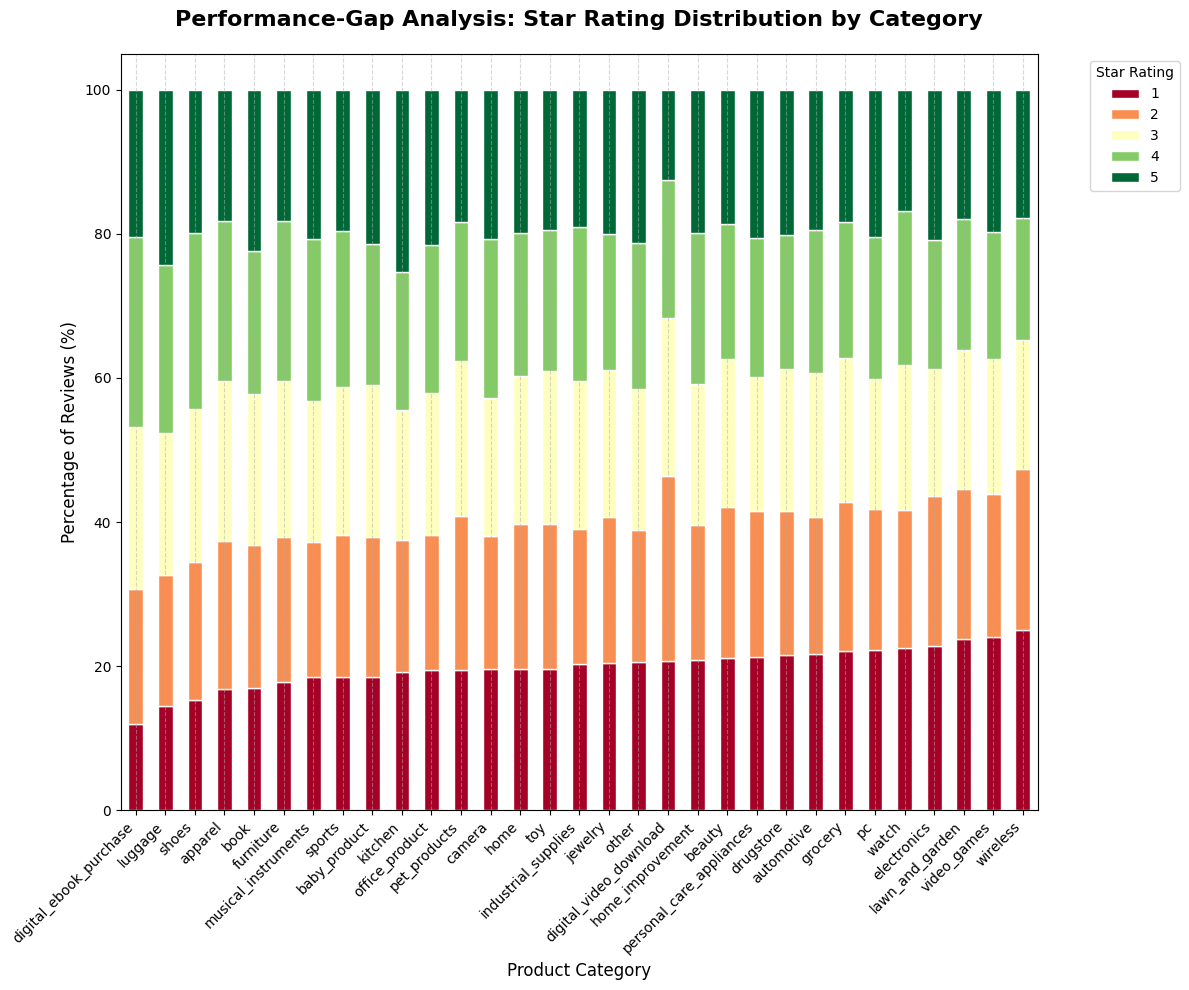

In [31]:
# PHASE 2.1: Performance-Gap Analysis (Kategorien-Benchmark)

# Create a normalized crosstab and sort by 1-star ratings (ascending)
ct_analysis = pd.crosstab(df['product_category'], 
                          df['stars'], 
                          normalize='index') * 100
ct_analysis = ct_analysis.sort_values(by=1, ascending=True)
display(ct_analysis.round(2))

# Setup the visualization using the object-oriented API
fig, ax = plt.subplots(figsize=(12, 10))
ct_analysis.plot(kind='bar', 
                 stacked=True,  
                 colormap='RdYlGn', 
                 edgecolor='white', 
                 ax=ax)

# Professional Styling and Labeling
ax.set_title('Performance-Gap Analysis: Star Rating Distribution by Category', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Percentage of Reviews (%)', fontsize=12)
ax.set_xlabel('Product Category', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.legend(title='Star Rating', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
ax.axvline(x=50, color='black', linestyle='--', alpha=0.3)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)

fig.tight_layout()

### **Phase 2.1 Analysis Insights** 🔍

**Observation:**
*   The sorting clearly shows a significant **Performance Gap** between product categories.
*   **Worst Performers (Risk Zones):** The categories **"wireless"**, **"pc"**, and **"lawn_and_garden"** have the highest concentration of 1-star reviews (approx. **24%**). This suggests frequent product defects or unmet customer expectations.
*   **Best Performers:** **"digital_ebook_purchase"** and **"luggage"** maintain the highest loyalty with only **11-12%** of 1-star ratings.

**Statistical Note:**
With a dataset of **1.26M reviews**, these gaps are statistically significant and not due to random chance. The ~12% difference in extreme dissatisfaction between categories is a major area for business optimization.